In [1]:
import pandas as pd

BC = pd.read_csv("SEER.csv")

In [2]:
!pip install lifelines
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from lifelines import CoxPHFitter
import matplotlib.pyplot as plt

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 8.8 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=add36d706f43251c9937130763a8d5f95a69996a02d0d86b7da975244da5a241
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [6]:
ER_pos = BC[BC['Estrogen Status'] == 'Positive']
ER_neg = BC[BC['Estrogen Status'] == 'Negative']

BC['Event'] = 0
BC.loc[BC['Status'] == 'Dead', 'Event'] = 1

In [4]:
BC.head(5)

,Age,Race,Marital Status,Unnamed: 3,T Stage,N Stage,6th Stage,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status,Event
0,43,"Other (American Indian/AK Native, Asian/Pacifi...",Married (including common law),NaN,T2,N3,IIIC,Moderately differentiated; Grade II,Regional,40,Positive,Positive,19,11,1,Alive,0
1,47,"Other (American Indian/AK Native, Asian/Pacifi...",Married (including common law),NaN,T2,N2,IIIA,Moderately differentiated; Grade II,Regional,45,Positive,Positive,25,9,2,Alive,0
2,67,White,Married (including common law),NaN,T2,N1,IIB,Poorly differentiated; Grade III,Regional,25,Positive,Positive,4,1,2,Dead,1
3,46,White,Divorced,NaN,T1,N1,IIA,Moderately differentiated; Grade II,Regional,19,Positive,Positive,26,1,2,Dead,1
4,63,White,Married (including common law),NaN,T2,N2,IIIA,Moderately differentiated; Grade II,Regional,35,Positive,Positive,21,5,3,Dead,1


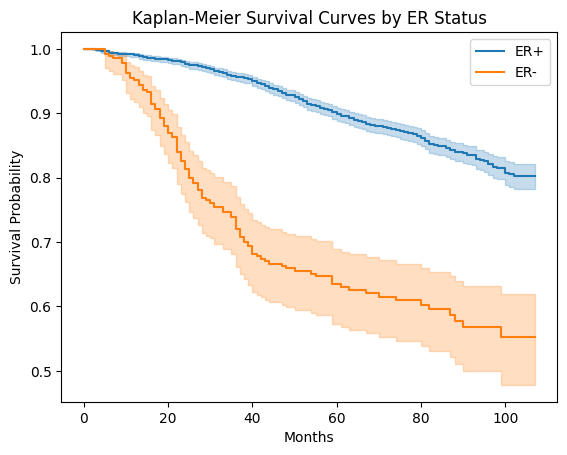

In [7]:
kmf = KaplanMeierFitter()
kmf.fit(ER_pos['Survival Months'], event_observed=ER_pos['Event'], label='ER+')
ax = kmf.plot_survival_function()

kmf.fit(ER_neg['Survival Months'], event_observed=ER_neg['Event'], label='ER-')
kmf.plot_survival_function(ax=ax)

plt.title("Kaplan-Meier Survival Curves by ER Status")
plt.xlabel("Months")
plt.ylabel("Survival Probability")
plt.show()
plt.show()

In [8]:
results = logrank_test(
    ER_pos['Survival Months'],
    ER_neg['Survival Months'],
    event_observed_A= ER_pos['Event'],
    event_observed_B= ER_neg['Event'])
print("Log-rank test p-value:", results.p_value)

Log-rank test p-value: 2.4240047814185683e-39


In [9]:
cox_model = BC[['Survival Months', 'Event', 'Estrogen Status']].copy()
cox_model['ERstatus'] = 0
cox_model.loc[BC['Estrogen Status'] == 'Positive', 'ERstatus'] = 1

In [10]:
cph = CoxPHFitter()
cph.fit(cox_model[['Survival Months', 'Event', 'ERstatus']],
        duration_col='Survival Months',
        event_col='Event')
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 4024 total observations, 3408 right-censored observations>
             duration col = 'Survival Months'
                event col = 'Event'
      baseline estimation = breslow
   number of observations = 4024
number of events observed = 616
   partial log-likelihood = -4862.71
         time fit was run = 2026-03-20 13:39:26 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
ERstatus  -1.30      0.27      0.11           -1.51           -1.09                0.22                0.34

           cmp to      z      p  -log2(p)
covariate                                
ERstatus     0.00 -12.25 <0.005    112.26
---
Concordance = 0.57
Partial AIC = 9727.43
log-likelihood ratio test = 112.51 on 1 df
-log2(p) of ll-ratio test = 84.91

In [11]:
BC.head(5)

,Age,Race,Marital Status,Unnamed: 3,T Stage,N Stage,6th Stage,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status,Event
0,43,"Other (American Indian/AK Native, Asian/Pacifi...",Married (including common law),NaN,T2,N3,IIIC,Moderately differentiated; Grade II,Regional,40,Positive,Positive,19,11,1,Alive,0
1,47,"Other (American Indian/AK Native, Asian/Pacifi...",Married (including common law),NaN,T2,N2,IIIA,Moderately differentiated; Grade II,Regional,45,Positive,Positive,25,9,2,Alive,0
2,67,White,Married (including common law),NaN,T2,N1,IIB,Poorly differentiated; Grade III,Regional,25,Positive,Positive,4,1,2,Dead,1
3,46,White,Divorced,NaN,T1,N1,IIA,Moderately differentiated; Grade II,Regional,19,Positive,Positive,26,1,2,Dead,1
4,63,White,Married (including common law),NaN,T2,N2,IIIA,Moderately differentiated; Grade II,Regional,35,Positive,Positive,21,5,3,Dead,1


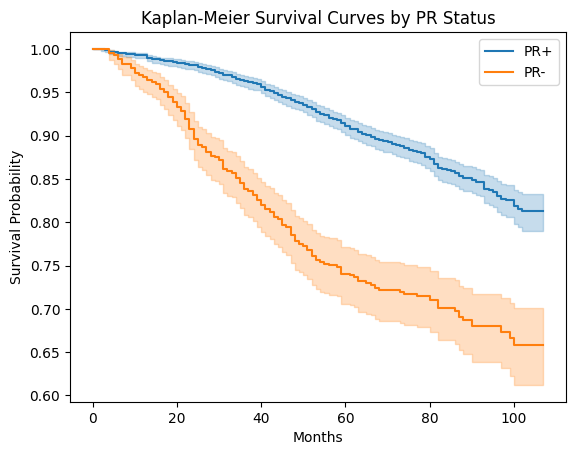

In [12]:
PR_pos = BC[BC['Progesterone Status'] == 'Positive']
PR_neg = BC[BC['Progesterone Status'] == 'Negative']

kmf.fit(PR_pos['Survival Months'], event_observed=PR_pos['Event'], label='PR+')
ax = kmf.plot_survival_function()

kmf.fit(PR_neg['Survival Months'], event_observed=PR_neg['Event'], label = 'PR-')
kmf.plot_survival_function(ax=ax)

plt.title("Kaplan-Meier Survival Curves by PR Status")
plt.xlabel("Months")
plt.ylabel("Survival Probability")
plt.show()
plt.show()

In [13]:
cox_model2 = BC[['Survival Months', 'Event', 'Progesterone Status']].copy()
cox_model2['PRstatus'] = 0
cox_model2.loc[BC['Progesterone Status'] == 'Positive', 'PRstatus'] = 1

In [14]:
cph = CoxPHFitter()
cph.fit(cox_model2[['Survival Months', 'Event', 'PRstatus']],
        duration_col='Survival Months',
        event_col='Event')
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 4024 total observations, 3408 right-censored observations>
             duration col = 'Survival Months'
                event col = 'Event'
      baseline estimation = breslow
   number of observations = 4024
number of events observed = 616
   partial log-likelihood = -4864.38
         time fit was run = 2026-03-20 13:39:39 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
PRstatus  -0.96      0.38      0.09           -1.12           -0.79                0.32                0.45

           cmp to      z      p  -log2(p)
covariate                                
PRstatus     0.00 -11.17 <0.005     93.76
---
Concordance = 0.60
Partial AIC = 9730.76
log-likelihood ratio test = 109.18 on 1 df
-log2(p) of ll-ratio test = 82.48

## Tumor size Analysis

In [34]:
cox_model_final = BC[['Survival Months', 'Event', 'Tumor Size',
                      'Estrogen Status', 'Progesterone Status']].copy()
cox_model_final['ERstatus'] = (cox_model_final['Estrogen Status'] == 'Positive').astype(int)
cox_model_final['PRstatus'] = (cox_model_final['Progesterone Status'] == 'Positive').astype(int)
cox_model_finala = cox_model_final.drop(columns=['Estrogen Status', 'Progesterone Status'])

cph = CoxPHFitter()
cph.fit(cox_model_finala,
        duration_col='Survival Months',
        event_col='Event')

cph.print_summary()

<lifelines.CoxPHFitter: fitted with 4024 total observations, 3408 right-censored observations>
             duration col = 'Survival Months'
                event col = 'Event'
      baseline estimation = breslow
   number of observations = 4024
number of events observed = 616
   partial log-likelihood = -4816.71
         time fit was run = 2026-03-20 15:32:12 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
Tumor Size  0.01      1.01      0.00            0.01            0.02                1.01                1.02
ERstatus   -0.84      0.43      0.13           -1.10           -0.59                0.33                0.56
PRstatus   -0.59      0.55      0.11           -0.80           -0.39                0.45                0.68

            cmp to     z      p  -log2(p)
covariate                                
Tumor Size    0.00  8.23 <0.005     52.26
ERstatus      0.00 -6.47 <0.005     33.23
PRstatus      0.00 -5.64 <0.005     25.79
---
Concordance = 0.66
Partial AIC = 9639.43
log-likelihood ratio test = 204.52 on 3 df
-log2(p) of ll-ratio test = 144.01

In [41]:
nodes_positive = BC[BC['Reginol Node Positive'] > 0]
min_size_for_positive_nodes = nodes_positive['Tumor Size'].min()
print("Minimum tumor size with positive nodes:", min_size_for_positive_nodes, "mm")

Minimum tumor size with positive nodes: 1 mm


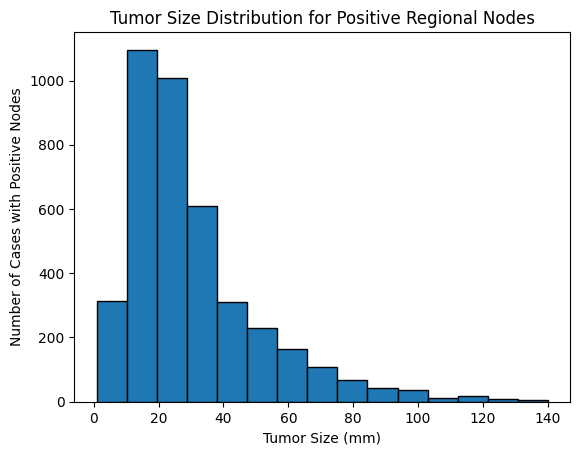

In [43]:
import matplotlib.pyplot as plt

plt.hist(nodes_positive['Tumor Size'], bins=15, edgecolor='black')
plt.xlabel("Tumor Size (mm)")
plt.ylabel("Number of Cases with Positive Nodes")
plt.title("Tumor Size Distribution for Positive Regional Nodes")
plt.show()

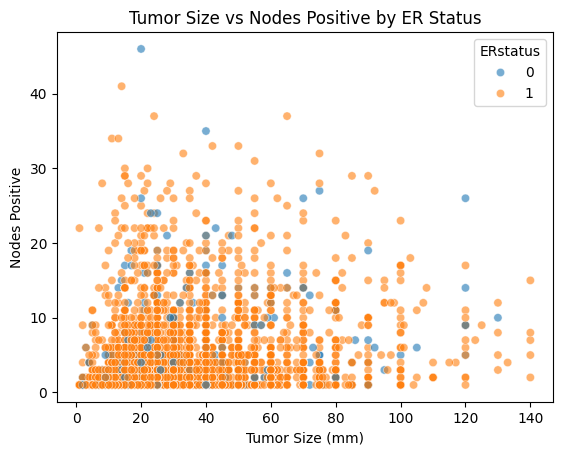

In [39]:
Scatter_plt = BC[['Survival Months', 'Event', 'Tumor Size',
                      'Estrogen Status', 'Progesterone Status', 'Reginol Node Positive']].copy()
Scatter_plt['ERstatus'] = (Scatter_plt['Estrogen Status'] == 'Positive').astype(int)
sns.scatterplot(x='Tumor Size', y='Reginol Node Positive', hue='ERstatus', data=Scatter_plt, alpha=0.6)
plt.title("Tumor Size vs Nodes Positive by ER Status")
plt.xlabel("Tumor Size (mm)")
plt.ylabel("Nodes Positive")
plt.show()

In [44]:
from scipy.stats import ttest_ind
regional = BC[BC['A Stage'] == 'Regional'] ['Tumor Size']
distant = BC[BC['A Stage'] == 'Distant'] ['Tumor Size']

t_stat, p = ttest_ind(regional, distant)
print("t-statistic:", t_stat)
print("p-value:", p)

t-statistic: -7.9175475340054735
p-value: 3.1086756111043266e-15


In [45]:
BC["Stage_code"] = 0
BC.loc[BC["A Stage"] == "Regional", "Stage_code"] = 1
BC.loc[BC["A Stage"] == "Distant", "Stage_code"] = 2
from scipy.stats import kendalltau

tau, p = kendalltau(BC['Tumor Size'], BC['Stage_code'])
print("Kendall's tau:", tau)
print("p-value:", p)

Kendall's tau: 0.08801482126211475
p-value: 1.6021193961384357e-11


## Race and Marital Status Analysis

In [16]:
from scipy.stats import chi2_contingency

In [17]:
cross_table = pd.crosstab(BC['Race '], BC['Grade'])
chi2, p, dof, expected = chi2_contingency(cross_table)
print("Chi-squared statistic:", chi2)
print("p-value:", p)

Chi-squared statistic: 27.90280218465802
p-value: 9.800668803416034e-05


In [18]:
table = pd.crosstab(BC['Race '], BC['Grade'])
row_percent = table.div(table.sum(axis=1), axis=0) * 100

print(row_percent)

Grade                                               Moderately differentiated; Grade II  \
Race                                                                                      
Black                                                                         48.453608   
Other (American Indian/AK Native, Asian/Pacific...                            56.250000   
White                                                                         59.478465   

Grade                                               Poorly differentiated; Grade III  \
Race                                                                                   
Black                                                                      39.518900   
Other (American Indian/AK Native, Asian/Pacific...                         29.375000   
White                                                                      26.428362   

Grade                                               Undifferentiated; anaplastic; Grade IV  \
Race     

<Axes: xlabel='Race '>

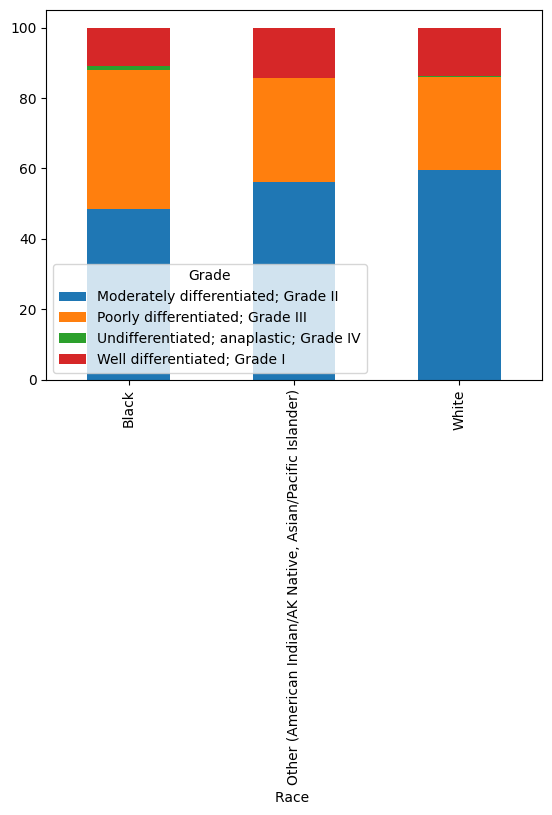

In [19]:
row_percent.plot(kind='bar', stacked=True)

In [24]:
cox_model_final2 = BC[['Survival Months', 'Event', 'Age',
                      'Race ', 'Marital Status']].copy()
cox_model_final2['Racecode'] = cox_model_final2['Race '].map({
    'White': 1,
    'Black': 2,
    'Other (American Indian/AK Native, Asian/Pacific Islander)': 3
})
cox_model_final2['Marital_code'] = cox_model_final2['Marital Status'].map({
    'Divorced': 4,
    'Married (including common law)': 2,
    'Separated': 3,
    'Widowed': 5,
    'Single (never married)': 1
})
cox_model_final2 = cox_model_final2.drop(columns=['Race '])
cox_model_final2 = cox_model_final2.drop(columns=['Marital Status'])

cph = CoxPHFitter()
cph.fit(cox_model_final2,
        duration_col='Survival Months',
        event_col='Event')

cph.print_summary()

<lifelines.CoxPHFitter: fitted with 4024 total observations, 3408 right-censored observations>
             duration col = 'Survival Months'
                event col = 'Event'
      baseline estimation = breslow
   number of observations = 4024
number of events observed = 616
   partial log-likelihood = -4910.89
         time fit was run = 2026-03-20 13:39:55 UTC

---
              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                     
Age           0.01      1.01      0.00            0.00            0.02                1.00                1.02
Racecode      0.00      1.00      0.07           -0.13            0.14                0.87                1.15
Marital_code  0.08      1.08      0.04            0.01            0.15                1.01                1.16

              cmp to    z      p  -log2(p)
covariate                                 
Age             0.00 2.88 <0.005      7.96
Racecode        0.00 0.05   0.96      0.05
Marital_code    0.00 2.16   0.03      5.03
---
Concordance = 0.54
Partial AIC = 9827.78
log-likelihood ratio test = 16.17 on 3 df
-log2(p) of ll-ratio test = 9.90

In [26]:
table1 = pd.crosstab(BC['Marital Status'], BC['Estrogen Status'])

print(table1)

chi2, p, dof, expected = chi2_contingency(table1)

print("Chi-square:", chi2)
print("p-value:", p)

Estrogen Status                 Negative  Positive
Marital Status                                    
Divorced                              27       459
Married (including common law)       173      2470
Separated                              7        38
Single (never married)                47       568
Widowed                               15       220
Chi-square: 7.690335600708195
p-value: 0.1036033180774431


In [29]:
table_percent = pd.crosstab(
    BC['Marital Status'],
    BC['Estrogen Status'],
    normalize='index'
) * 100
print(table_percent)

Estrogen Status                  Negative   Positive
Marital Status                                      
Divorced                         5.555556  94.444444
Married (including common law)   6.545592  93.454408
Separated                       15.555556  84.444444
Single (never married)           7.642276  92.357724
Widowed                          6.382979  93.617021


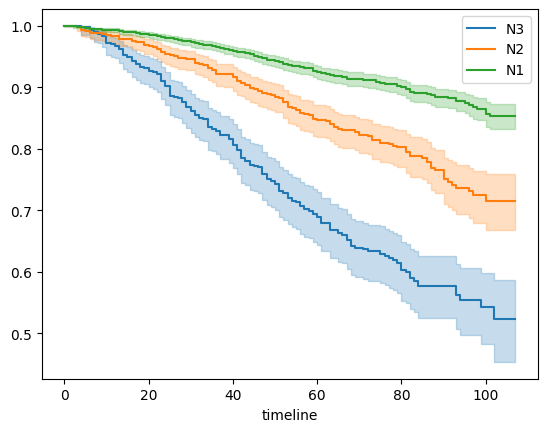

In [30]:
kmf = KaplanMeierFitter()

for stage in BC['N Stage'].unique():
    subset = BC[BC['N Stage'] == stage]
    kmf.fit(subset['Survival Months'], subset['Event'], label=stage)
    kmf.plot()

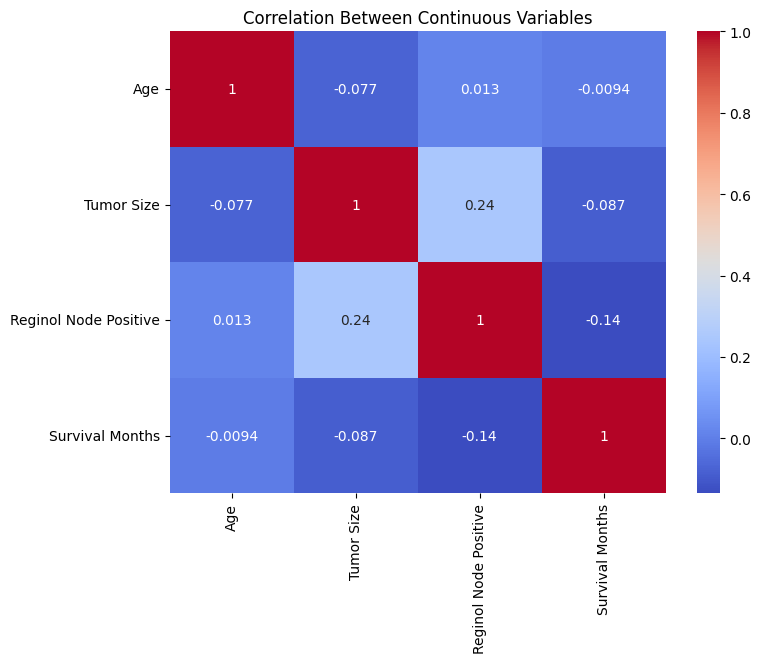

In [33]:
import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(BC[['Age','Tumor Size','Reginol Node Positive','Survival Months']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Continuous Variables")
plt.show()